In [20]:
import numpy as np
import getdist.plots
import matplotlib.pyplot as plt
import yaml
import sys
import os

# Load parameter configuration files
# params_names.yaml contains the mapping from parameter names to LaTeX labels
with open("params_names.yaml", "r") as file:
    params_dic = yaml.safe_load(file)

# params_model_shear.yaml contains fiducial values and prior ranges
with open("params_model_shear.yaml", "r") as file:
    fiducials = yaml.safe_load(file)


In [21]:
# Set up plotting style and colors
import seaborn as sns
sns.set_theme(style="ticks")
colors = sns.color_palette("Set2")  # Use seaborn Set2 color palette

# Use matplotlib's built-in text (no LaTeX required)
from matplotlib import rc
rc('text', usetex=False)
rc('font', **{'family': 'serif', 'serif': ['DejaVu Serif']})


In [22]:
chain_3b = np.load('../sampling/chains/chain_checkpoint_3x2pt_DR1_area_1589_realistic_new_covmat_TR1v1.1_binned_wz_step_3bins.npz', allow_pickle=True)

chain_3b['fiducial']

array({'H0': 67, 'Omega_cdm0': 0.27, 'Omega_b0': 0.049, 'Omega_k0': 0.0, 'mnu': 0.077, 'w0': -0.75, 'wa': -0.86, 'ns': 0.96, 'As': 2.1e-09, 'gamma_MG': 0.545, 'log10TAGN': 7.75, 'N_mnu': 1, 'N_eff': 3.046, 'zbin_edges': array([0.0e+00, 7.0e-01, 1.4e+00, 2.1e+00, 1.0e+03]), 'w_i': array([-0.97296296, -1.1904878 , -1.29727273, -1.60828702]), 'binning': 'step', 'AIA': 0.16, 'EtaIA': 1.66, 'CIA': 0.0134, 'b1_photo_poly0': 1.33291, 'b1_photo_poly1': -0.72414, 'b1_photo_poly2': 1.0183, 'b1_photo_poly3': -0.14913, 'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0, 'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0, 'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0, 'magnification_bias_7': 0.0, 'magnification_bias_8': 0.0, 'magnification_bias_9': 0.0, 'magnification_bias_10': 0.0, 'magnification_bias_11': 0.0, 'magnification_bias_12': 0.0, 'magnification_bias_13': 0.0, 'dz_pos_1': 0.0, 'dz_pos_2': 0.0, 'dz_pos_3': 0.0, 'dz_pos_4': 0.0, 'dz_pos_5': 0.0, 'dz_pos_6': 0.0, 'dz_

In [23]:
chain = np.load('../sampling/chains/chain_checkpoint_3x2pt_DR1_area_1589_realistic_new_covmat_TR1v1.1_cpl.npz', allow_pickle=True)


In [24]:
#chain, derived, weights, logl, param_names,derived_names,logz,chain_time, chain_time_hms, fiducial
fiducials  = chain['fiducial'].flat[0]
fiducials['h'] = fiducials['H0']/100.
fiducials['logAs'] = np.log(1e10*fiducials['As'])
fiducials['omch2'] = fiducials['Omega_cdm0']*fiducials['h']*fiducials['h']
fiducials['ombh2'] = fiducials['Omega_b0']*fiducials['h']*fiducials['h']
fiducials['sigma8_0'] = 0.8120011480183122
fiducials['Omega_m'] = (fiducials['omch2']+fiducials['ombh2']+fiducials['mnu']/93.14)/fiducials['h']**2
fiducials['S8'] = fiducials['sigma8_0']*np.sqrt(fiducials['Omega_m']/0.3)


In [25]:
# List of MCMC chain files to compare
file_paths = ['../sampling/chains/chain_checkpoint_3x2pt_DR1_area_1589_realistic_new_covmat_TR1v1.1_cpl.npz',
             '../sampling/chains/chain_checkpoint_3x2pt_DR1_area_1589_realistic_new_covmat_TR1v1.1_binned_wz_step_3bins.npz',
             '../sampling/chains/chain_checkpoint_3x2pt_DR1_area_1589_realistic_new_covmat_TR1v1.1_binned_wz_smoothedstep_3bins.npz',
             '../sampling/chains/chain_checkpoint_3x2pt_DR1_area_1589_realistic_new_covmat_TR1v1.1_binned_wz_desi_3bins.npz'
 ]  

# Legend labels for each chain (LaTeX formatting supported)
legend_labels = [
    'CPL',
    'step',
    'smoothed step',
    'DESI'
]

n_samples = len(file_paths)
chains_info = {}

# Load each MCMC chain file
for i in range(n_samples):
    file_path = file_paths[i]  
    
    # Load numerical data from chain file
    chain_npz = np.load(file_path, allow_pickle=True)
        
    
    # Store chain data and parameter names
    chains_info[i] = {}
    chains_info[i]['chain'] = np.vstack([chain_npz['chain'].flat[0][par] for par in chain_npz['param_names']]).T
    chains_info[i]['chain'] = np.hstack((chains_info[i]['chain'], chain_npz['derived'].flat[0]['sigma8_0'][:, np.newaxis]))
    print(chains_info[i]['chain'].shape)
    chains_info[i]['weights'] = chain_npz['weights']
    chains_info[i]['logl'] = chain_npz['logl']
    chains_info[i]['pars'] = np.hstack((chain_npz['param_names'], chain['derived_names']))
    chains_info[i]['fiducial'] = chain_npz['fiducial'].flat[0]
    print(chain_npz['chain_time_hms'])
    if 'w_i' in chains_info[i]['fiducial']:
        for j in range(len(chains_info[i]['fiducial']['w_i'])):
            chains_info[i]['fiducial']['w'+str(j+1)] = chains_info[i]['fiducial']['w_i'][j]

(31496, 32)
0:00:00.000788
(32364, 34)
0:00:00.000790
(32860, 34)
8:26:56.290052
(33232, 35)
6:18:37.805536


In [26]:
# =============================================================================
# GETDIST SAMPLE PREPARATION
# =============================================================================

samples = []    
for i in range(n_samples):
    # Create GetDist MCSamples object for each chain
    samples.append(
        getdist.MCSamples(
            # Sample data (excluding log-likelihood and weight columns)
            samples = chains_info[i]['chain'],
            # Parameter names
            names = [i for i in chains_info[i]['pars']],
            # Sample weights (exponential of log-likelihood)
            weights=np.exp(chains_info[i]['weights']),
            # LaTeX labels for parameters (from params_dic)
            labels = [params_dic[p] for p in chains_info[i]['pars']],
            # Smoothing settings for 1D and 2D distributions
            settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35},
            # Parameter ranges for plotting
            #ranges = Ranges
        ) 
    )
    mnu = chains_info[i]['fiducial']['mnu']
    # Get parameter object (unused but kept for compatibility)
    p = samples[i].getParams() 
    samples[i].addDerived(p.H0/100., 'h','h')
    p = samples[i].getParams() 
    samples[i].addDerived((p.omch2+p.ombh2+mnu/93.14)/p.h**2, 'Omega_m','\Omega_{\\rm m}')
    p = samples[i].getParams() 
    samples[i].addDerived(p.sigma8_0*np.sqrt(p.Omega_m/0.3), 'S8', 'S_8')


Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


In [27]:
# Create GetDist subplot plotter
g = getdist.plots.getSubplotPlotter(subplot_size=1.3)

# Configure plot appearance settings
plt.rcParams.update({'font.size':16})
g.settings.legend_fontsize=22      # Legend text size
g.settings.axes_fontsize=18        # Axis tick labels size  
g.settings.axes_labelsize=20       # Axis labels size
g.settings.linewidth=4             # Contour line width
g.settings.figure_legend_frame = False  # Remove legend frame


In [28]:
chains_info[0]['pars']

array(['omch2', 'ombh2', 'H0', 'logAs', 'ns', 'AIA', 'EtaIA', 'w0', 'wa',
       'b1_photo_poly0', 'b1_photo_poly1', 'b1_photo_poly2',
       'b1_photo_poly3', 'multiplicative_bias_1', 'multiplicative_bias_2',
       'multiplicative_bias_3', 'multiplicative_bias_4',
       'multiplicative_bias_5', 'multiplicative_bias_6', 'dz_pos_1',
       'dz_pos_2', 'dz_pos_3', 'dz_pos_4', 'dz_pos_5', 'dz_pos_6',
       'dz_shear_1', 'dz_shear_2', 'dz_shear_3', 'dz_shear_4',
       'dz_shear_5', 'dz_shear_6', 'sigma8_0'], dtype='<U21')

In [29]:
ModelPars = ['Omega_m', 'S8',  'h', 'w0', 'wa']

Text(1.1, 0.1, '3x2pt,\n TR1 $n(z)$,\n DR1 covariance,\n DESI CPL fiducial,\n CMB priors,\n $\\ell_{\\rm max}=1500, 750$')

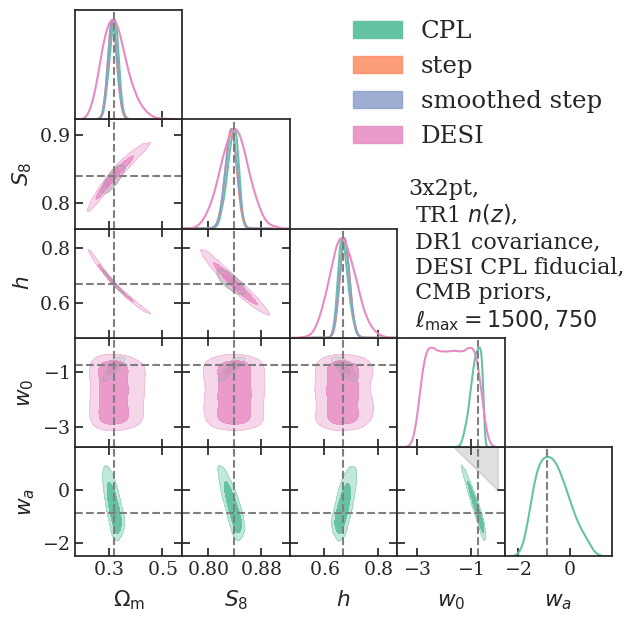

In [30]:
# =============================================================================
# CREATE TRIANGLE PLOT
# =============================================================================

# Generate the main triangle (corner) plot
g.triangle_plot(
    samples,                          # List of MCSamples objects
    ModelPars,                        # Parameters to include in plot
    legend_labels = legend_labels,    # Labels for legend
    legend_loc = 'upper right',       # Legend position
    # Filled contour styling for each sample
    contour_args = [
        {'filled':True, 'color': colors[0]}, 
        {'filled':True, 'color': colors[1], 'ls': '-'}, 
        {'filled':True, 'color': colors[2], 'ls': '-'},
        {'filled':True, 'color': colors[3], 'ls': '-'},  
        {'filled':True, 'color': colors[4], 'ls': '-'},  
        {'filled':True, 'color': colors[5], 'ls': '-'}
    ], 
    # 1D marginalized distribution styling
    line_args=[
        {'color': colors[0], 'ls': '-'}, 
        {'color': colors[1], 'ls': '-'}, 
        {'color': colors[2], 'ls': '-'}, 
        {'color': colors[3], 'ls': '-'}, 
        {'color': colors[4], 'ls': '-'}, 
        {'color': colors[5], 'ls': '-'}
    ]
)

xx = np.linspace(-2., 0., 100)

if fiducials != None:
    for i in range(len(ModelPars)):
        for j in range(i+1):
            ax = g.subplots[i,j]
            
            # Add horizontal line for fiducial value of y-parameter (for 2D plots)
            if i != j and ModelPars[i] in fiducials and fiducials[ModelPars[i]] != None:
                ax.axhline(fiducials[ModelPars[i]], lw=1.5, color='tab:gray', linestyle='--')
                if ModelPars[i] == 'wa' and ModelPars[j] == 'w0':
                    #ax.plot(xx, -xx, color='tab:gray', linestyle='--')
                    ax.fill_between(xx, -xx, np.ones(len(xx))*4, color='grey', alpha=0.25)
            # Add vertical line for fiducial value of x-parameter
            if ModelPars[j] in fiducials and fiducials[ModelPars[j]] != None:
                ax.axvline(fiducials[ModelPars[j]], lw=1.5, color='tab:gray', linestyle='--')

# Position for annotation (subplot index)
num = 2
annotation_text = '3x2pt,\n TR1 $n(z)$,\n DR1 covariance,\n DESI CPL fiducial,\n CMB priors,\n $\ell_{\\rm max}=1500, 750$'
# Add text annotation to a specific subplot
ax = g.subplots[num, num]
ax.annotate(annotation_text, (1.1, 0.1), xycoords='axes fraction', 
           clip_on=False, fontsize=16) 

In [31]:
ModelPars = ['w0','w1', 'w2', 'w3', 'w4']

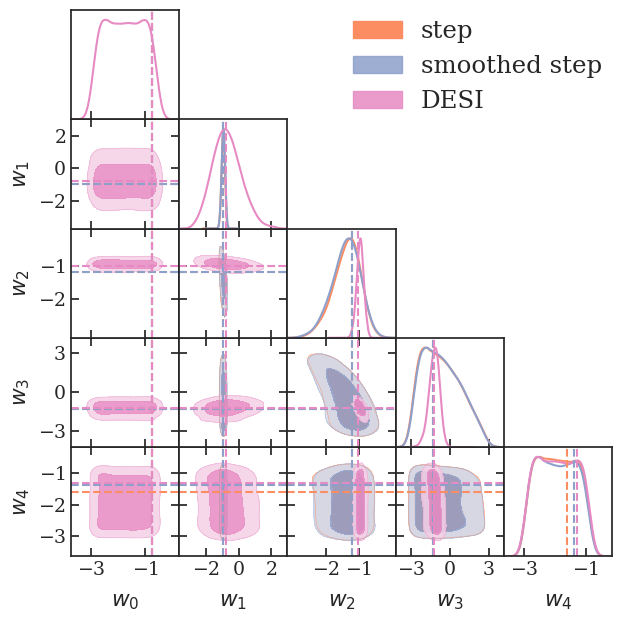

In [32]:
# Generate the main triangle (corner) plot
g.triangle_plot(
    samples[1:],                          # List of MCSamples objects
    ModelPars,                        # Parameters to include in plot
    legend_labels = legend_labels[1:],    # Labels for legend
    legend_loc = 'upper right',       # Legend position
    # Filled contour styling for each sample
    contour_args = [
       # {'filled':True, 'color': colors[0]}, 
        {'filled':True, 'color': colors[1], 'ls': '-'}, 
        {'filled':True, 'color': colors[2], 'ls': '-'},
        {'filled':True, 'color': colors[3], 'ls': '-'},  
        {'filled':True, 'color': colors[4], 'ls': '-'},  
        {'filled':True, 'color': colors[5], 'ls': '-'}
    ], 
    # 1D marginalized distribution styling
    line_args=[
       # {'color': colors[0], 'ls': '-'}, 
        {'color': colors[1], 'ls': '-'}, 
        {'color': colors[2], 'ls': '-'}, 
        {'color': colors[3], 'ls': '-'}, 
        {'color': colors[4], 'ls': '-'}, 
        {'color': colors[5], 'ls': '-'}
    ]
)
for num in range(4):
    for i in range(len(ModelPars)):
        for j in range(i+1):
            ax = g.subplots[i,j]
            #print(chains_info[num]['fiducial'])
            # Add horizontal line for fiducial value of y-parameter (for 2D plots)
            #print(ModelPars[i], ModelPars[i] in chains_info[num]['fiducial'])
            if i != j and ModelPars[i] in chains_info[num]['fiducial'] and chains_info[num]['fiducial'][ModelPars[i]] != None:
                ax.axhline(chains_info[num]['fiducial'][ModelPars[i]], lw=1.5, color=colors[num], linestyle='--')
                #print('here')
            
            # Add vertical line for fiducial value of x-parameter
            if ModelPars[j] in chains_info[num]['fiducial'] and chains_info[num]['fiducial'][ModelPars[j]] != None:
                ax.axvline(chains_info[num]['fiducial'][ModelPars[j]], lw=1.5, color=colors[num], linestyle='--')

In [33]:
marge = samples[0].getMargeStats()
cpl_chain = {}
for par in ['w0', 'wa']:
    # Get the ParamInfo for your parameter (e.g. 'w0')
    p = marge.parWithName(par)

    # Mean (same as samples[0].mean('w0') when using sample mean)
    mean = p.mean

    # limit=1 → 68% interval; limit=2 → 95% interval
    # Lower and upper bounds
    low_68, high_68 = p.limits[0].lower, p.limits[0].upper   # 68%
    low_95, high_95 = p.limits[1].lower, p.limits[1].upper   # 95%

    # As “two errors” (asymmetric): plus_err = upper - mean, minus_err = mean - lower
    plus_err_68  = p.limits[0].upper - p.mean
    minus_err_68 = p.mean - p.limits[0].lower

    plus_err_95  = p.limits[1].upper - p.mean
    minus_err_95 = p.mean - p.limits[1].lower

    #print(mean, plus_err_68, minus_err_68)
    #print(mean, plus_err_95, minus_err_95)
    cpl_chain[par] = {'mean': mean, 'plus_err_68': plus_err_68, 'minus_err_68': minus_err_68, 'plus_err_95': plus_err_95, 'minus_err_95': minus_err_95}


In [34]:
# Pivot scale for w0-wa (CPL): a_piv = 1 + Cov(w0,wa)/Var(wa), using weighted covariance
w0 = samples[0].samples[:, samples[0].index['w0']]
wa = samples[0].samples[:, samples[0].index['wa']]
weights = samples[0].weights
if weights is None:
    weights = np.ones(len(w0), dtype=float)
else:
    weights = np.asarray(weights, dtype=float)
weights = weights / np.sum(weights)
mean_w0 = np.average(w0, weights=weights)
mean_wa = np.average(wa, weights=weights)
cov_01 = np.average((w0 - mean_w0) * (wa - mean_wa), weights=weights)
var_wa = np.average((wa - mean_wa)**2, weights=weights)
a_piv = 1 + cov_01 / var_wa
z_piv = 1.0 / a_piv - 1.0
print(f"a_piv = {a_piv:.4f}, z_piv = {z_piv:.4f}")

a_piv = 0.6929, z_piv = 0.4433


In [35]:
bin_chain ={}
names = ['3 bins', '4 bins', '5 bins']
bins = [['w1', 'w2', 'w3', 'w4'], ['w1', 'w2', 'w3', 'w4', 'w5'], ['w1', 'w2', 'w3', 'w4', 'w5', 'w6']]

for i in range(3):    
    marge = samples[i+1].getMargeStats()
    bin_chain[names[i]] = {}
    zbin_edges = chains_info[i+1]['fiducial']['zbin_edges']
    mean_all = []
    plus_err_68_all = []
    minus_err_68_all = []
    plus_err_95_all = []
    minus_err_95_all = []
    for par in bins[i]:
        # Get the ParamInfo for your parameter (e.g. 'w0')
        p = marge.parWithName(par)

        # Mean (same as samples[0].mean('w0') when using sample mean)
        mean = p.mean

        # limit=1 → 68% interval; limit=2 → 95% interval
        # Lower and upper bounds
        low_68, high_68 = p.limits[0].lower, p.limits[0].upper   # 68%
        low_95, high_95 = p.limits[1].lower, p.limits[1].upper   # 95%

        # As “two errors” (asymmetric): plus_err = upper - mean, minus_err = mean - lower
        plus_err_68  = p.limits[0].upper - p.mean
        minus_err_68 = p.mean - p.limits[0].lower

        plus_err_95  = p.limits[1].upper - p.mean
        minus_err_95 = p.mean - p.limits[1].lower

        zbin_centers = 0.5*(zbin_edges[1:] + zbin_edges[:-1])
        mean_all.append(mean)
        plus_err_68_all.append(plus_err_68)
        minus_err_68_all.append(minus_err_68)
        plus_err_95_all.append(plus_err_95)
        minus_err_95_all.append(minus_err_95)


    bin_chain[names[i]] = {'mean': mean_all, 'plus_err_68': plus_err_68_all, 'minus_err_68': minus_err_68_all, 'plus_err_95': plus_err_95_all, 'minus_err_95': minus_err_95_all, 'zbin_centers': zbin_centers}


AttributeError: 'NoneType' object has no attribute 'mean'

In [18]:
# Pivot redshift

w0 = samples[0].samples[:, samples[0].index['w0']]
wa = samples[0].samples[:, samples[0].index['wa']]
a_piv = 1+np.cov(w0, wa, aweights=samples[0].weights)[0, 1]/np.cov(w0, wa, aweights=samples[0].weights)[1, 1]
z_piv = 1./a_piv -1.
print(f"a_piv = {a_piv:.4f}, z_piv = {z_piv:.4f}")
a_piv = 1+np.cov(w0, wa, aweights=samples[0].weights)[0, 1]/np.cov(w0, wa, aweights=samples[0].weights)[1, 1]
z_piv = 1./a_piv -1.
print(f"a_piv = {a_piv:.4f}, z_piv = {z_piv:.4f}")

a_piv = 0.6929, z_piv = 0.4433
a_piv = 0.6929, z_piv = 0.4433


KeyError: 'zbin_centers'

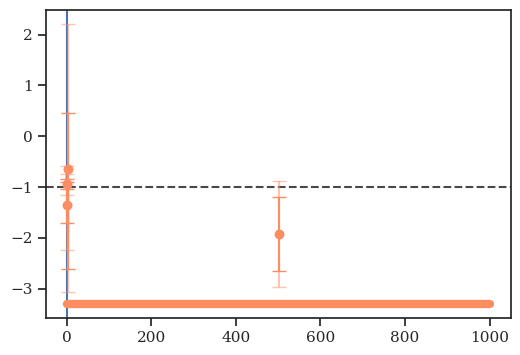

In [ ]:
# Redshift
z = np.linspace(0.0, 3., 200)


w0, wa = fiducials['w0'], fiducials['wa']
w_fid = w0 + wa * z / (1 + z)

# Confidence bands (template widths: narrow at low z, wider at high z)
w_chain = cpl_chain['w0']['mean'] + cpl_chain['wa']['mean'] * z / (1 + z)
# Scale uncertainty with z for template
sigma_lo = np.sqrt(cpl_chain['w0']['minus_err_68']**2 + (z / (1 + z))**2 * cpl_chain['wa']['minus_err_68']**2)
sigma_hi = np.sqrt(cpl_chain['w0']['plus_err_68']**2 + (z / (1 + z))**2 * cpl_chain['wa']['plus_err_68']**2)
sigma2_lo = np.sqrt(cpl_chain['w0']['minus_err_95']**2 + (z / (1 + z))**2 * cpl_chain['wa']['minus_err_95']**2)
sigma2_hi = np.sqrt(cpl_chain['w0']['plus_err_95']**2 + (z / (1 + z))**2 * cpl_chain['wa']['plus_err_95']**2)

w_chain_68_lo = w_chain - sigma_lo
w_chain_68_hi = w_chain + sigma_hi
w_chain_95_lo = w_chain - sigma2_lo
w_chain_95_hi = w_chain + sigma2_hi

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(z, w_chain, color=colors[0], lw=1.5, label='CPL chain')
# 95% band 
ax.fill_between(z, w_chain_95_lo, w_chain_95_hi, color=colors[0], alpha=0.25)
# 68% band 
ax.fill_between(z, w_chain_68_lo, w_chain_68_hi, color=colors[0], alpha=0.45)

ax.plot(z, w_fid, 'k-', lw=1.5, label='CPL fiducial')
ax.axvline(x=z_piv, label=r'$z_{\rm piv}$')
# Reference line w = -1
ax.axhline(-1.0, color='k', ls='--', lw=1.5, alpha=0.8)

for i in range(3):
    ax.errorbar(bin_chain[names[i]]['zbin_centers'], bin_chain[names[i]]['mean'], yerr=[bin_chain[names[i]]['minus_err_68'], bin_chain[names[i]]['plus_err_68']], color=colors[i+1], linestyle='', marker='o', capsize=5, label=names[i])
    ax.errorbar(bin_chain[names[i]]['zbin_centers'], bin_chain[names[i]]['mean'], yerr=[bin_chain[names[i]]['minus_err_95'], bin_chain[names[i]]['plus_err_95']], color=colors[i+1], linestyle='', marker='o', alpha=0.5, capsize=5)
    for j in range(len(chains_info[i+1]['fiducial']['zbin_edges'])-1):
        x = np.linspace(chains_info[i+1]['fiducial']['zbin_edges'][j], chains_info[i+1]['fiducial']['zbin_edges'][j+1]-0.05, 100)
        ax.plot(x, -3.3*np.ones(100)*(1+0.1*i), color=colors[i+1], lw=6)
ax.set_xlim(0, 2.5)
#ax.set_ylim(-2.0, -0.4)
ax.set_xlabel(r'$z$')
ax.set_ylabel(r'$w(z)$')
ax.grid(True, alpha=0.3)
#ax.axvline(x=2.1)
ax.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()
